# 05 · Bike-Sharing — Model Interpretability (PDP & SHAP)

## Part 5 — Explaining the Model (Interpretability)

Parts 3–4 built a strong forecaster and showed *that* lags dominate — but a number in a feature-
importance list is not understanding. A model you can't explain is hard to trust, debug, or deploy
(and "why did demand drop?" is a real stakeholder question). This notebook opens the black box with
the standard interpretability toolkit, applied to the LightGBM demand model:

1. **Global importance** three ways — *gain* vs *permutation* vs *mean |SHAP|* — and why they can
   disagree.
2. **Partial dependence** — the *shape* of each effect (the nonlinear temperature curve, the commute
   profile) that a linear model could never express.
3. **Interactions** — the hour effect *depends on* the working day; temperature *depends on* the hour.
4. **SHAP** — a principled, additive attribution: global **beeswarm**, **local** explanations of
   single predictions, and a **dependence** plot that exposes interactions.
5. The **caveats** every honest interpretability analysis must state.

It brings the EDA mindset — *understand before you trust* — to the model itself.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb, shap
from sklearn.inspection import permutation_importance, partial_dependence
from src import featurize as fz, backtest as bt

g = bt.add_strict_lags(data.regular_grid()); y = g["cnt"]
COLS = fz.CALENDAR + fz.WEATHER + bt.STRICT_LAGS
X = g[COLS].astype(float)                       # float so sklearn PDP accepts it
n = len(g); H = 14 * 24; trm = slice(168, n - H); tem = slice(n - H, n)
mdl = lgb.LGBMRegressor(n_estimators=500, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1).fit(X.iloc[trm], y.iloc[trm])
expl = shap.TreeExplainer(mdl)
samp = X.iloc[trm].sample(2000, random_state=0)
sv = expl.shap_values(samp)
print("model trained | SHAP base value (avg prediction) = %.0f rentals" % float(expl.expected_value))

setup ok | numpy 2.1.3 | pandas 2.3.3


model trained | SHAP base value (avg prediction) = 191 rentals


### 1. Global importance — three lenses that can disagree

- **Gain** (LightGBM-native): total loss reduction from splits on a feature — *training-set* view,
  biased toward high-cardinality features.
- **Permutation**: shuffle a feature on held-out data and watch accuracy drop — *model-agnostic*,
  measures real predictive reliance, but splits credit oddly among correlated features.
- **mean |SHAP|**: average absolute contribution per prediction — additive and consistent, in the
  units of the target (rentals).

All three put the **recent-demand lags on top** — but watch **hour**: permutation and SHAP rank it
among the most important features, while **gain buries it** (its predictive credit was absorbed by
the lags at the first splits). The *same model* gives opposite verdicts on a key feature — which is
exactly why you never trust a single importance number.

            gain%  perm(ΔRMSE)  mean|SHAP|
lag168       70.5         30.5        74.4
lag24        13.7         19.7        32.1
hr            3.5         26.4        29.3
temp_C        2.0          4.3        20.6
yr            0.3          0.0        14.0
hum_pct       2.2         10.7        12.4
weathersit    2.9         10.9         9.6
dow           1.5          0.3         7.8
workingday    0.8          5.3         5.8
lag_dayavg    1.1          3.2         4.6
mnth          0.5          0.0         3.0
wind_kmh      0.5          0.6         2.8
season        0.2          1.3         2.5
holiday       0.4          4.5         1.1


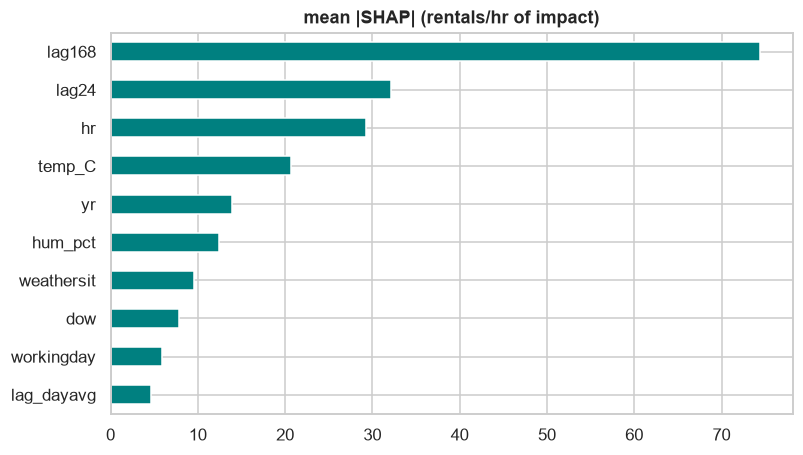

In [2]:
gain = pd.Series(mdl.booster_.feature_importance("gain"), index=COLS); gain /= gain.sum()
perm = pd.Series(permutation_importance(mdl, X.iloc[tem], y.iloc[tem], n_repeats=5, random_state=0,
                 scoring="neg_root_mean_squared_error").importances_mean, index=COLS)
shap_imp = pd.Series(np.abs(sv).mean(0), index=COLS)
comp = pd.DataFrame({"gain%": (gain*100).round(1), "perm(ΔRMSE)": perm.round(1),
                     "mean|SHAP|": shap_imp.round(1)}).sort_values("mean|SHAP|", ascending=False)
print(comp.to_string())
fig, ax = plt.subplots(figsize=(8, 4.5))
shap_imp.sort_values().tail(10).plot.barh(ax=ax, color="teal"); ax.set_title("mean |SHAP| (rentals/hr of impact)")
eda.savefig(fig, "p5_importance.png"); plt.show()

### 2. Partial dependence — the *shape* of each effect

Importance says *how much*; partial dependence says *which way and what shape*. We average the
model's prediction as one feature sweeps its range. This reveals the **nonlinearities** the Part-3
linear model couldn't capture: temperature helps up to ~25–30 °C then **saturates/falls** (too hot
to ride); demand falls with humidity; and the hour profile is the familiar twin commute peaks.

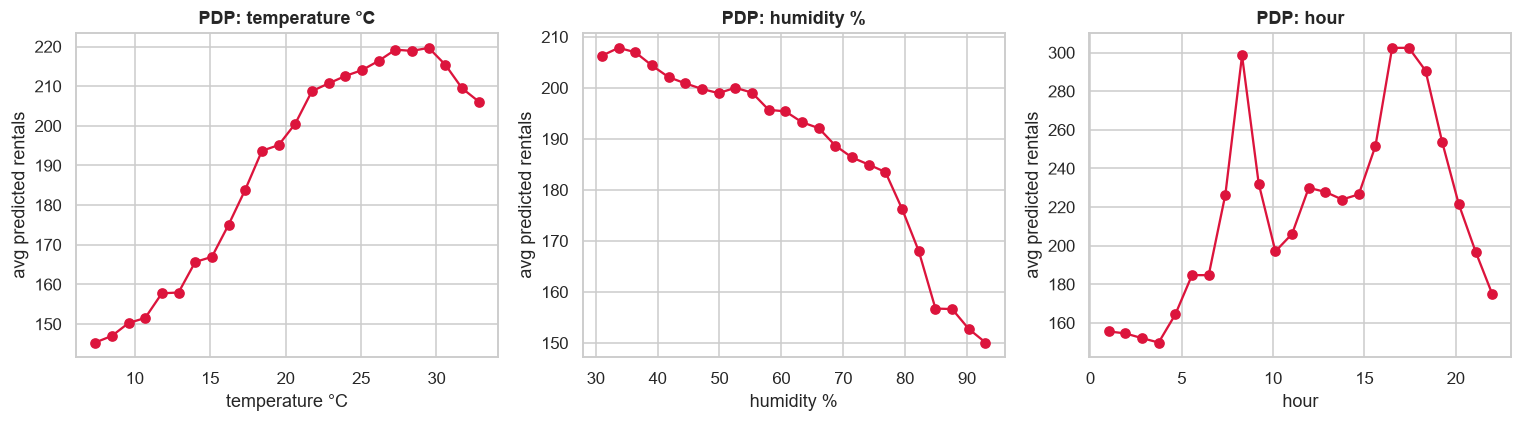

temperature effect peaks near 29°C, then demand stops rising (saturation).


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, feat, lab in zip(ax, ["temp_C", "hum_pct", "hr"], ["temperature °C", "humidity %", "hour"]):
    pdp = partial_dependence(mdl, samp, [feat], grid_resolution=24)
    a.plot(pdp["grid_values"][0], pdp["average"][0], "o-", color="crimson")
    a.set_xlabel(lab); a.set_ylabel("avg predicted rentals"); a.set_title(f"PDP: {lab}")
fig.tight_layout(); eda.savefig(fig, "p5_pdp.png"); plt.show()
pt = partial_dependence(mdl, samp, ["temp_C"], grid_resolution=24)
peak_t = pt["grid_values"][0][np.argmax(pt["average"][0])]
print("temperature effect peaks near %.0f°C, then demand stops rising (saturation)." % peak_t)

### 3. The key interaction — hour × working day

A single hour-of-day curve is a lie (Part 1 showed it): the commute peaks exist **only on working
days**, while weekends are a midday hump. A tree captures this **interaction** for free — we expose
it by sweeping the hour with `workingday` fixed to each value (other features at their median).

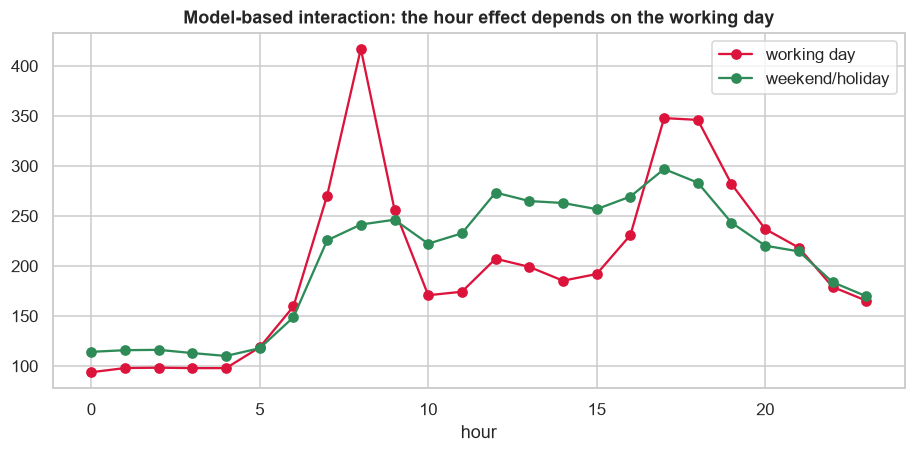

working-day peak hour = 8, weekend peak hour = 17  (the model learned the two rider populations)


In [4]:
base = samp.median(); rows = []
for wd in (0, 1):
    for h in range(24):
        r = base.copy(); r["hr"] = h; r["workingday"] = wd; rows.append(r)
G = pd.DataFrame(rows); G["pred"] = mdl.predict(G[COLS]); piv = G.pivot_table("pred", "hr", "workingday")
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(piv.index, piv[1], "o-", color="crimson", label="working day")
ax.plot(piv.index, piv[0], "o-", color="seagreen", label="weekend/holiday")
ax.set_title("Model-based interaction: the hour effect depends on the working day"); ax.set_xlabel("hour"); ax.legend()
eda.savefig(fig, "p5_interaction.png"); plt.show()
print("working-day peak hour = %d, weekend peak hour = %d  (the model learned the two rider populations)"
      % (piv[1].idxmax(), piv[0].idxmax()))

### 4. SHAP — a principled attribution

**SHAP** values come from cooperative game theory: they distribute each prediction's gap from the
**base value** (average demand) fairly among the features, and they **add up exactly** to the
prediction. The **beeswarm** shows, for every feature, the distribution of its SHAP impact across
2,000 hours, coloured by the feature's value — so you read *direction*, *magnitude*, and *spread* at
once.

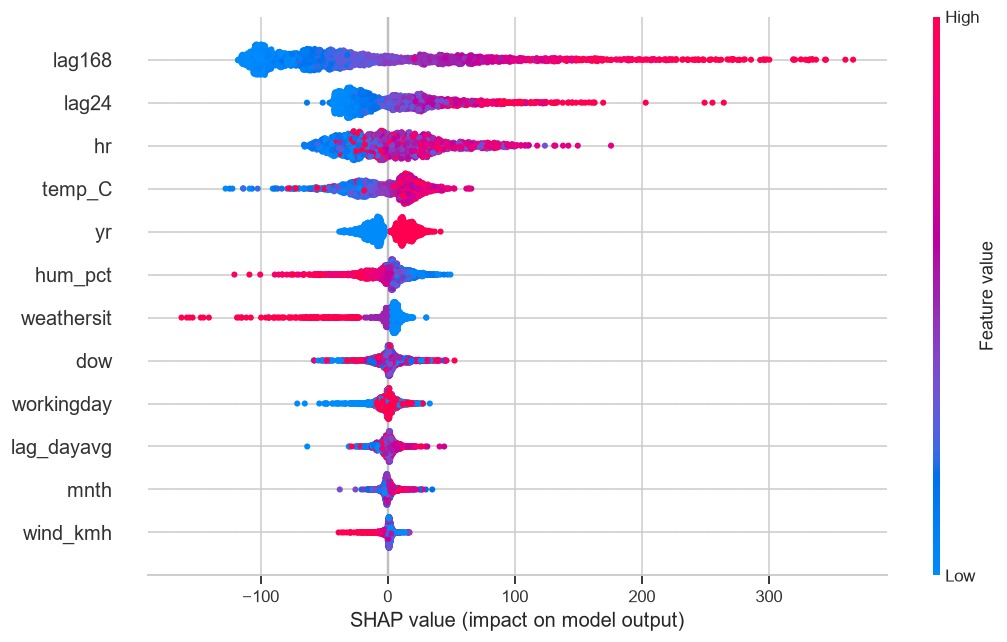

In [5]:
plt.figure(); shap.summary_plot(sv, samp, show=False, plot_size=(10, 6), max_display=12)
eda.savefig(plt.gcf(), "p5_shap_beeswarm.png"); plt.show()

Read it: high `lag168`/`lag24` (red) push demand **up** by hundreds of rentals; warm `temp_C`
(red) pushes up; high `hum_pct` (red) pushes **down**; `hr` fans out both ways (rush hours up, night
down). The colour-impact alignment *is* the direction of each effect.

### 5. Local explanations — *why this hour?*

SHAP's real power is per-prediction. We explain two opposite hours: a **busy 6pm working-day**
commute and a **quiet 4am**. Each prediction = base value + the feature contributions, so you can
hand a stakeholder the exact reason for any forecast.

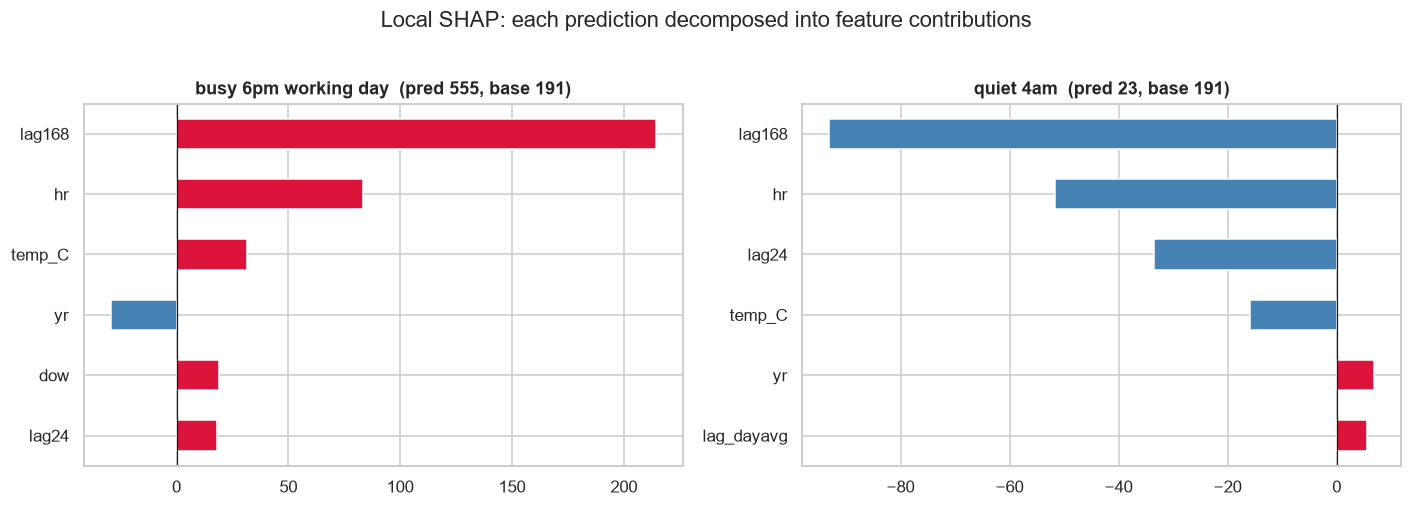

In [6]:
def explain(mask, title):
    inst = samp[mask].head(1)
    contrib = pd.Series(expl.shap_values(inst)[0], index=COLS).sort_values(key=abs, ascending=False).head(6)
    return inst, contrib, float(mdl.predict(inst[COLS])[0])
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, (mask, title) in zip(ax, [((samp.hr == 18) & (samp.workingday == 1), "busy 6pm working day"),
                                  ((samp.hr == 4), "quiet 4am")]):
    _, contrib, pred = explain(mask, title)
    colors = ["crimson" if v > 0 else "steelblue" for v in contrib]
    contrib[::-1].plot.barh(ax=a, color=colors[::-1])
    a.axvline(0, color="k", lw=.8); a.set_title(f"{title}  (pred {pred:.0f}, base {expl.expected_value:.0f})")
fig.suptitle("Local SHAP: each prediction decomposed into feature contributions", y=1.02)
fig.tight_layout(); eda.savefig(fig, "p5_shap_local.png"); plt.show()

### 6. SHAP dependence — interactions made visible

A SHAP **dependence** plot puts one feature's value on x and its SHAP impact on y, **coloured by an
interacting feature**. Temperature coloured by hour shows that warmth helps *much more at busy
hours* than at night — the interaction the global PDP averaged away.

<Figure size 704x528 with 0 Axes>

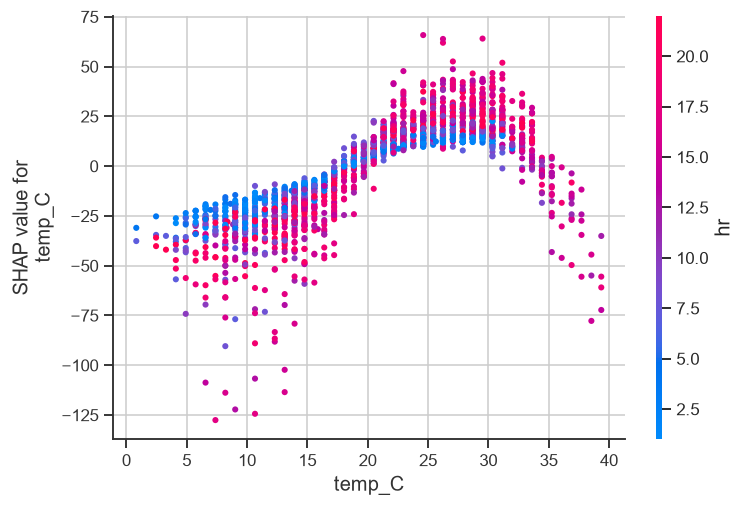

temp's effect on demand is larger (steeper SHAP) during high-traffic hours -> a real interaction.


In [7]:
plt.figure(); shap.dependence_plot("temp_C", sv, samp, interaction_index="hr", show=False)
eda.savefig(plt.gcf(), "p5_shap_dependence.png"); plt.show()
print("temp's effect on demand is larger (steeper SHAP) during high-traffic hours -> a real interaction.")

### 7. The caveats every honest analysis must state

- **PDP/ICE assume feature independence.** Sweeping `temp_C` to 35 °C in January is a combination
  that never occurs — the curve there is an extrapolation, not evidence.
- **Importance ≠ causation.** `lag168` is the strongest *predictor*, not a *cause* of demand;
  intervening on it would do nothing. These tools explain the **model**, not the world.
- **Correlated features split credit.** `temp_C` and `atemp_C` (and the lags) share signal, so any
  single-feature attribution is partly arbitrary among them.
- **SHAP is an approximation** of a complex function and is computed on a *sample*; treat the ranks
  as robust, the exact values as estimates.

### 8. Takeaways

- **Three importance lenses** (gain / permutation / SHAP) broadly agree — recent-demand lags and
  hour dominate — but disagree in the details; cross-check, never trust one.
- **Partial dependence** reveals *shape*: temperature **saturates** (~25–30 °C then falls), humidity
  hurts, the hour is a twin-peak commute — the nonlinearities the linear model of Part 3 missed.
- The decisive **hour × working-day interaction** (and temp × hour) is captured by the tree and made
  visible by PDP and SHAP dependence — the model rediscovered Part 1's two rider populations.
- **SHAP** gives additive, per-prediction explanations you can hand to a stakeholder — and a global
  beeswarm that shows direction + magnitude + spread together.
- Interpretability explains the **model, not the world**: mind feature independence, correlation,
  and the predictor-vs-cause distinction.

*This rounds out the bike-sharing practice — EDA → multi-seasonal TS → covariate forecasting →
probabilistic backtesting → interpretability — a complete, honest demand-forecasting study.*